In [10]:
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets
import torch
from torchvision import transforms
from transformers import AutoImageProcessor
from torch.utils.data import DataLoader
from transformers import ViTForImageClassification
from transformers import TrainingArguments, Trainer

In [27]:
def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.targets):
        target_idx[int(label)].append(idx)

    indices = list(chain.from_iterable([target_idx[idx][:max_len] for idx in range(len(classes))]))
    return Subset(dataset, indices)

train_dataset = datasets.FashionMNIST(root='./datasets', download=True, train=True)
test_dataset = datasets.FashionMNIST(root='./datasets', download=True, train=False)


In [17]:
def model_init(classes, class_to_idx):
    model = ViTForImageClassification.from_pretrained(
        pretrained_model_name_or_path="google/vit-base-patch16-224-in21k",
        num_labels=len(classes),
        id2label={idx: label for label, idx in class_to_idx.items()},
        label2id=class_to_idx,
    )
    return model


In [18]:
classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

print(classes)
print(class_to_idx)

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

print(len(subset_train_dataset))
print(len(subset_test_dataset))


['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
10000
1000


In [19]:


image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path='google/vit-base-patch16-224-in21k'
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(image_processor.size['height'], image_processor.size['width'])
        ),
        transforms.Lambda(lambda x: torch.cat([x, x, x], 0)),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std,
        ),
    ]
)

print(image_processor.size)
print(image_processor.image_mean)
print(image_processor.image_std)


{'height': 224, 'width': 224}
[0.5, 0.5, 0.5]
[0.5, 0.5, 0.5]


In [20]:


def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {'pixel_values': pixel_values, 'labels': labels}

train_dataloader = DataLoader(
    subset_train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True,
)
valid_dataloader = DataLoader(
    subset_test_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True,
)

batch = next(iter(train_dataloader))
for key, value in batch.items():
    print(key, value.shape)


pixel_values torch.Size([32, 3, 224, 224])
labels torch.Size([32])


In [21]:


model = ViTForImageClassification.from_pretrained(
    pretrained_model_name_or_path="google/vit-base-patch16-224-in21k",
    num_labels=len(classes),
    id2label={idx: label for label, idx in class_to_idx.items()},
    label2id=class_to_idx,
    ignore_mismatched_sizes=True
)

print(model.classifier)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Linear(in_features=768, out_features=10, bias=True)


In [22]:
print(model.vit.embeddings)

batch = next(iter(train_dataloader))
print(batch["pixel_values"].shape)
print(model.vit.embeddings.patch_embeddings(batch["pixel_values"]).shape)
print(model.vit.embeddings(batch["pixel_values"]).shape)

ViTEmbeddings(
  (patch_embeddings): ViTPatchEmbeddings(
    (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (dropout): Dropout(p=0.0, inplace=False)
)
torch.Size([32, 3, 224, 224])
torch.Size([32, 196, 768])
torch.Size([32, 197, 768])


In [24]:
import evaluate
import numpy as np


def compute_metrics(eval_pred):
    metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = metric.compute(
        predictions=predictions, references=labels, average="macro"
    )
    return macro_f1

In [25]:
args = TrainingArguments(
    output_dir="../models/ViT-FashionMNIST",
    save_strategy="epoch",
    evaluation_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,
    seed=42
)

trainer = Trainer(
    model_init=lambda x: model_init(classes, class_to_idx),
    args=args,
    train_dataset=subset_train_dataset,
    eval_dataset=subset_test_dataset,
    data_collator=lambda x: collator(x, transform),
    compute_metrics=compute_metrics,
    tokenizer=image_processor,
)
trainer.train()

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/1875 [00:00<?, ?it/s]

{'loss': 1.9287, 'learning_rate': 9.333333333333334e-06, 'epoch': 0.2}
{'loss': 1.2745, 'learning_rate': 8.666666666666668e-06, 'epoch': 0.4}
{'loss': 0.9329, 'learning_rate': 8.000000000000001e-06, 'epoch': 0.6}
{'loss': 0.7791, 'learning_rate': 7.333333333333333e-06, 'epoch': 0.8}
{'loss': 0.706, 'learning_rate': 6.666666666666667e-06, 'epoch': 1.0}


  0%|          | 0/63 [00:00<?, ?it/s]

{'eval_loss': 0.640486478805542, 'eval_f1': 0.8873372269924854, 'eval_runtime': 9.2656, 'eval_samples_per_second': 107.926, 'eval_steps_per_second': 6.799, 'epoch': 1.0}
{'loss': 0.6159, 'learning_rate': 6e-06, 'epoch': 1.2}
{'loss': 0.5653, 'learning_rate': 5.333333333333334e-06, 'epoch': 1.4}
{'loss': 0.5191, 'learning_rate': 4.666666666666667e-06, 'epoch': 1.6}
{'loss': 0.4931, 'learning_rate': 4.000000000000001e-06, 'epoch': 1.8}
{'loss': 0.4837, 'learning_rate': 3.3333333333333333e-06, 'epoch': 2.0}


  0%|          | 0/63 [00:00<?, ?it/s]

{'eval_loss': 0.4711633026599884, 'eval_f1': 0.9196046156229365, 'eval_runtime': 8.8925, 'eval_samples_per_second': 112.454, 'eval_steps_per_second': 7.085, 'epoch': 2.0}
{'loss': 0.4423, 'learning_rate': 2.666666666666667e-06, 'epoch': 2.2}
{'loss': 0.4387, 'learning_rate': 2.0000000000000003e-06, 'epoch': 2.4}
{'loss': 0.412, 'learning_rate': 1.3333333333333334e-06, 'epoch': 2.6}
{'loss': 0.4148, 'learning_rate': 6.666666666666667e-07, 'epoch': 2.8}
{'loss': 0.4034, 'learning_rate': 0.0, 'epoch': 3.0}


  0%|          | 0/63 [00:00<?, ?it/s]

{'eval_loss': 0.43260011076927185, 'eval_f1': 0.9183649819612212, 'eval_runtime': 8.8568, 'eval_samples_per_second': 112.908, 'eval_steps_per_second': 7.113, 'epoch': 3.0}
{'train_runtime': 680.1573, 'train_samples_per_second': 44.107, 'train_steps_per_second': 2.757, 'train_loss': 0.693959804280599, 'epoch': 3.0}


TrainOutput(global_step=1875, training_loss=0.693959804280599, metrics={'train_runtime': 680.1573, 'train_samples_per_second': 44.107, 'train_steps_per_second': 2.757, 'train_loss': 0.693959804280599, 'epoch': 3.0})

  0%|          | 0/63 [00:00<?, ?it/s]

PredictionOutput(predictions=array([[ 2.8532581 , -0.46536204, -0.35564116, ..., -0.521868  ,
        -0.21606766, -0.46003258],
       [ 1.0080376 , -0.05764367, -0.15230301, ..., -0.79583216,
        -0.5659388 , -0.8624768 ],
       [ 2.8279467 , -0.54100615, -0.24955945, ..., -0.46544677,
        -0.22041088, -0.43489873],
       ...,
       [-0.47840753, -0.6043227 , -0.53710294, ...,  0.9384273 ,
        -0.05863226,  2.5789258 ],
       [-0.3982331 , -0.44909477, -0.33745813, ...,  0.29991356,
        -0.40995103,  3.2106397 ],
       [-0.3709343 , -0.28896108, -0.23840308, ..., -0.1214255 ,
        -0.31954157,  3.1891167 ]], dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

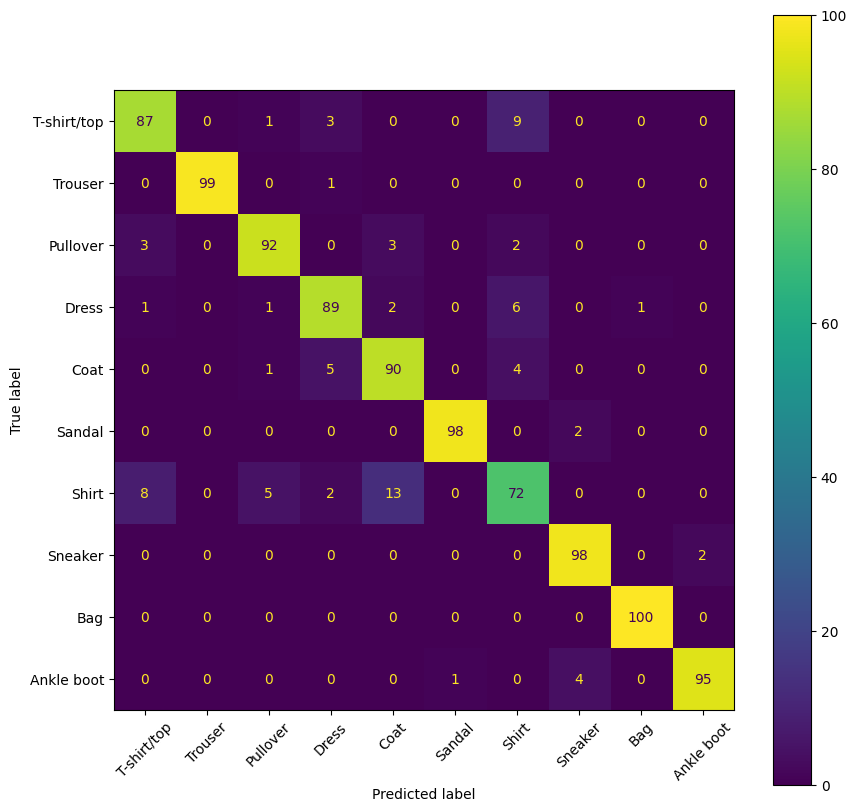

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


outputs = trainer.predict(subset_test_dataset)
print(outputs)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
_, ax = plt.subplots(figsize=(10, 10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()